Purpose: Investigate results of CAM gene TPM regression between parents & each Yg genotype.<br>
Author: Anna Pardo<br>
Date initiated: Mar. 9, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load results df
res = pd.read_csv("./Yg_parents_CAMgene_regression_results.txt",sep="\t",header="infer")
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique
0,YufilH1072272m.g,51,D,1.000000,1.000000,possible_fac_CAM,Yf,PPCK,Yf_PPCK_5
1,YufilH1034994m.g,15,D,0.999981,0.999963,facultative_CAM,Yf,NAD-MDH-cp,Yf_NAD-MDH-cp_3
2,YufilH1044442m.g,15,D,0.999935,0.999869,facultative_CAM,Yf,BPPC,Yf_BPPC
3,YufilH1032169m.g,52,D,0.995784,0.994378,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2
4,YufilH1032169m.g,1AB,D,0.994326,0.992907,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2


In [3]:
min(res["adjr2"])

-0.9994128407063736

In [4]:
# gene families of most interest (strongest time structuring): BPPC, PPPC, PPCK, PPDK, NAD-MDH-cp, NADP-ME
## for each genotype & gene: is the (adjusted) R2 higher for Ya or Yf-derived gene copies?
sg = []
for i in list(res["GeneID"]):
    if i.startswith("Yufil"):
        sg.append("Yf")
    else:
        sg.append("Ya")
res["subgenome"] = sg
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique,subgenome
0,YufilH1072272m.g,51,D,1.000000,1.000000,possible_fac_CAM,Yf,PPCK,Yf_PPCK_5,Yf
1,YufilH1034994m.g,15,D,0.999981,0.999963,facultative_CAM,Yf,NAD-MDH-cp,Yf_NAD-MDH-cp_3,Yf
2,YufilH1044442m.g,15,D,0.999935,0.999869,facultative_CAM,Yf,BPPC,Yf_BPPC,Yf
3,YufilH1032169m.g,52,D,0.995784,0.994378,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2,Yf
4,YufilH1032169m.g,1AB,D,0.994326,0.992907,possible_fac_CAM,Yf,PPCK,Yf_PPCK_2,Yf


In [5]:
len(res["gene_abbr"].unique())

12

In [6]:
res.sort_values(by=["gene_abbr","subgenome"],inplace=True)

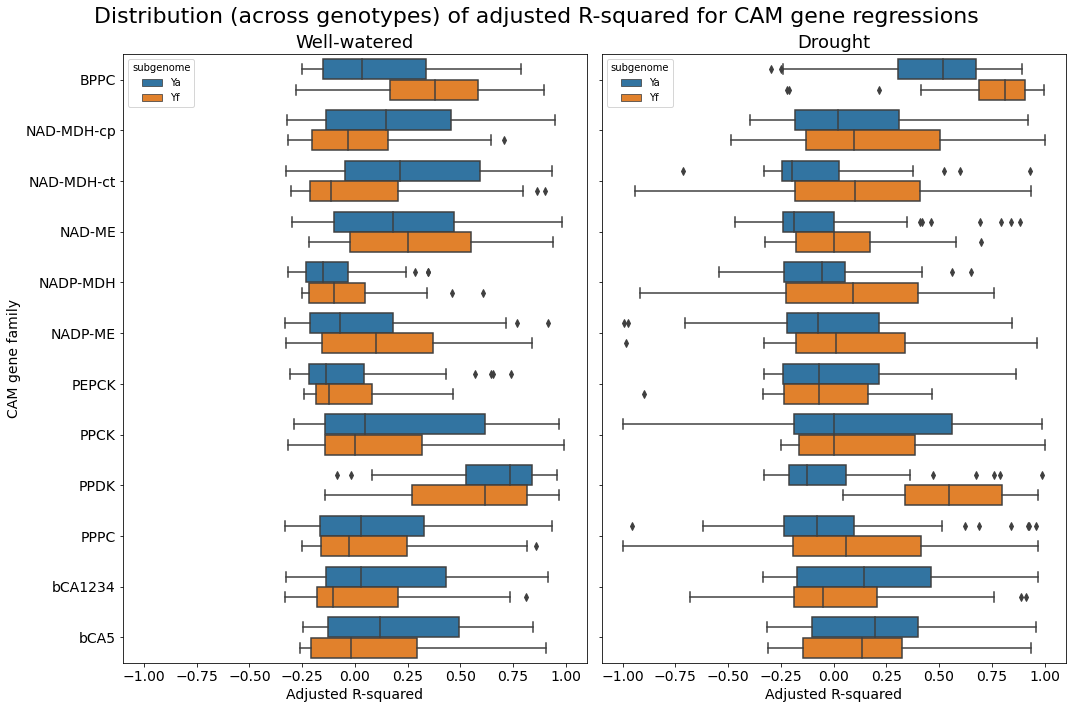

In [7]:
# make a boxplot: x=gene family, y=adjr2, hue=subgenome
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,10),sharey=True,sharex=True)
sns.boxplot(ax=ax[0],data=res[res["treatment"]=="W"],y="gene_abbr",x="adjr2",hue="subgenome")
ax[0].set_title("Well-watered",fontsize=18)
ax[0].set_xlabel("Adjusted R-squared",fontsize=14)
ax[0].tick_params(which="both",labelsize=14)
ax[0].set_ylabel("CAM gene family",fontsize=14)

sns.boxplot(ax=ax[1],data=res[res["treatment"]=="D"],y="gene_abbr",x="adjr2",hue="subgenome")
ax[1].set_title("Drought",fontsize=18)
ax[1].set_ylabel("")
ax[1].set_xlabel("Adjusted R-squared",fontsize=14)
ax[1].tick_params(which="both",labelsize=14)

plt.suptitle("Distribution (across genotypes) of adjusted R-squared for CAM gene regressions",fontsize=22)

fig.tight_layout()

plt.savefig("./adjR2_boxplot_bygenefam.png",dpi=200,bbox_inches="tight")
plt.savefig("./adjR2_boxplot_bygenefam.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./adjR2_boxplot_bygenefam.svg",dpi=200,bbox_inches="tight")

In [8]:
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique,subgenome
109,Yucal.07G108500.v2.1,6,D,0.913193,0.891492,NaN,Ya,BPPC,Ya_BPPC_3,Ya
128,Yucal.07G108300.v2.1,15,D,0.901019,0.802038,facultative_CAM,Ya,BPPC,Ya_BPPC_1,Ya
135,Yucal.07G108300.v2.1,56,D,0.897812,0.872265,C3,Ya,BPPC,Ya_BPPC_1,Ya
146,Yucal.07G108500.v2.1,61,D,0.888514,0.860643,C3,Ya,BPPC,Ya_BPPC_3,Ya
149,Yucal.07G108300.v2.1,61,D,0.886478,0.858098,C3,Ya,BPPC,Ya_BPPC_1,Ya


In [9]:
res["sgtreat"] = res["subgenome"]+"_"+res["treatment"]

In [10]:
# some promising results here for PPDK & BPPC, even with all genotypes lumped together
## repeat this for each genotype
def plot_r2_genotype(gt):
    df = res[res["genotype"]==gt]
    p = df["CAMphys"].unique()[0]
    if type(p)!=str:
        p = "no data"
    
    fig,ax = plt.subplots(figsize=(7,12))
    sns.boxplot(data=df,y="gene_abbr",x="adjr2",hue="sgtreat",hue_order=["Ya_W","Yf_W","Ya_D","Yf_D"],palette="tab20")
    ax.set_xlabel("Adjusted R-squared",fontsize=14)
    ax.tick_params(which="both",labelsize=14)
    ax.set_ylabel("CAM gene family",fontsize=14)

    plt.title("Adjusted R-squared for CAM gene regressions in genotype "+gt+" ("+p+")",fontsize=18)

    plt.savefig("./boxplots/adjR2_boxplot_bygenefam_"+gt+".png",dpi=200,bbox_inches="tight")
    plt.savefig("./boxplots/adjR2_boxplot_bygenefam_"+gt+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig("./boxplots/adjR2_boxplot_bygenefam_"+gt+".svg",dpi=200,bbox_inches="tight")

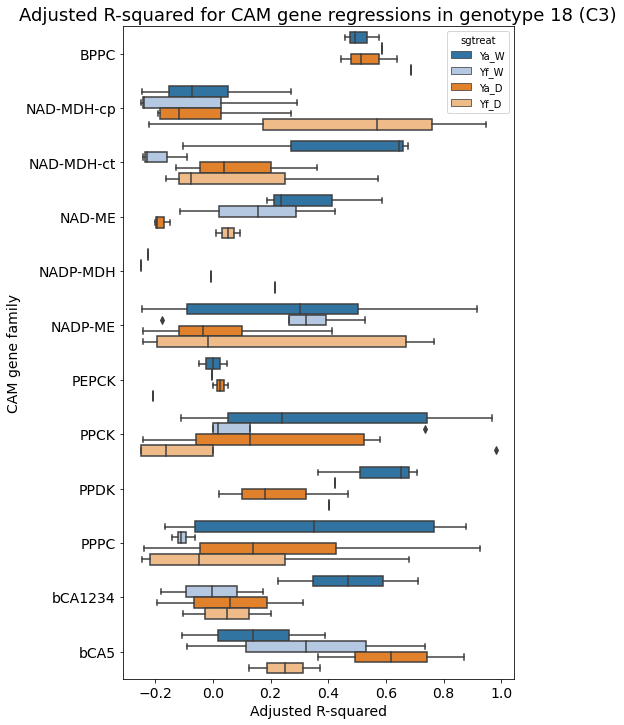

In [11]:
plot_r2_genotype("18")

In [12]:
# do this for all genotypes
for g in res["genotype"].unique():
    plot_r2_genotype(g)
    plt.cla()
    plt.clf()

/tmp/ipykernel_27327/1986953205.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots(figsize=(7,12))


<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

...

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

<Figure size 504x864 with 0 Axes>

## Mar. 18: Make a figure for poster

Figure to make: Show R-squared values by genotype physiology for three families in particular (PPPC, BPPC, PPCK). Probably a boxplot.

In [13]:
res.head()

,GeneID,genotype,treatment,r2,adjr2,CAMphys,comp_parent,gene_abbr,gene_abbr_unique,subgenome,sgtreat
109,Yucal.07G108500.v2.1,6,D,0.913193,0.891492,NaN,Ya,BPPC,Ya_BPPC_3,Ya,Ya_D
128,Yucal.07G108300.v2.1,15,D,0.901019,0.802038,facultative_CAM,Ya,BPPC,Ya_BPPC_1,Ya,Ya_D
135,Yucal.07G108300.v2.1,56,D,0.897812,0.872265,C3,Ya,BPPC,Ya_BPPC_1,Ya,Ya_D
146,Yucal.07G108500.v2.1,61,D,0.888514,0.860643,C3,Ya,BPPC,Ya_BPPC_3,Ya,Ya_D
149,Yucal.07G108300.v2.1,61,D,0.886478,0.858098,C3,Ya,BPPC,Ya_BPPC_1,Ya,Ya_D


In [24]:
def plot_fam(genefam,axc,axs=ax,leg=False):
    pres = res[res["gene_abbr"]==genefam]
    
    if leg!=False:
        sns.boxplot(ax=axs[axc],data=pres,x="CAMphys",y="adjr2",order=["C3","possible_fac_CAM","facultative_CAM"],
                    hue="sgtreat",hue_order=["Ya_W","Yf_W","Ya_D","Yf_D"],
                    palette="tab20")
        sns.stripplot(ax=axs[axc],data=pres,x="CAMphys",y="adjr2",order=["C3","possible_fac_CAM","facultative_CAM"],
                      hue="sgtreat",hue_order=["Ya_W","Yf_W","Ya_D","Yf_D"],
                     palette={
                         "Ya_W":"mediumblue",
                         "Yf_W":"dodgerblue",
                         "Ya_D":"orangered",
                         "Yf_D":"chocolate"
                     })
        axs[axc].legend(bbox_to_anchor=(1,1))
    else:
        sns.boxplot(ax=axs[axc],data=pres,x="CAMphys",y="adjr2",order=["C3","possible_fac_CAM","facultative_CAM"],
                    hue="sgtreat",hue_order=["Ya_W","Yf_W","Ya_D","Yf_D"],palette="tab20")
        sns.stripplot(ax=axs[axc],data=pres,x="CAMphys",y="adjr2",order=["C3","possible_fac_CAM","facultative_CAM"],
                      hue="sgtreat",hue_order=["Ya_W","Yf_W","Ya_D","Yf_D"],
                     palette={
                         "Ya_W":"mediumblue",
                         "Yf_W":"dodgerblue",
                         "Ya_D":"orangered",
                         "Yf_D":"chocolate"
                     },legend=False)
        axs[axc].get_legend().remove()
    
    axs[axc].tick_params(which="both",labelsize=16)
    axs[axc].set_xlabel("")
    axs[axc].set_ylabel("Adjusted R-squared",fontsize=16)
    axs[axc].set_title(genefam,fontsize=24)
    

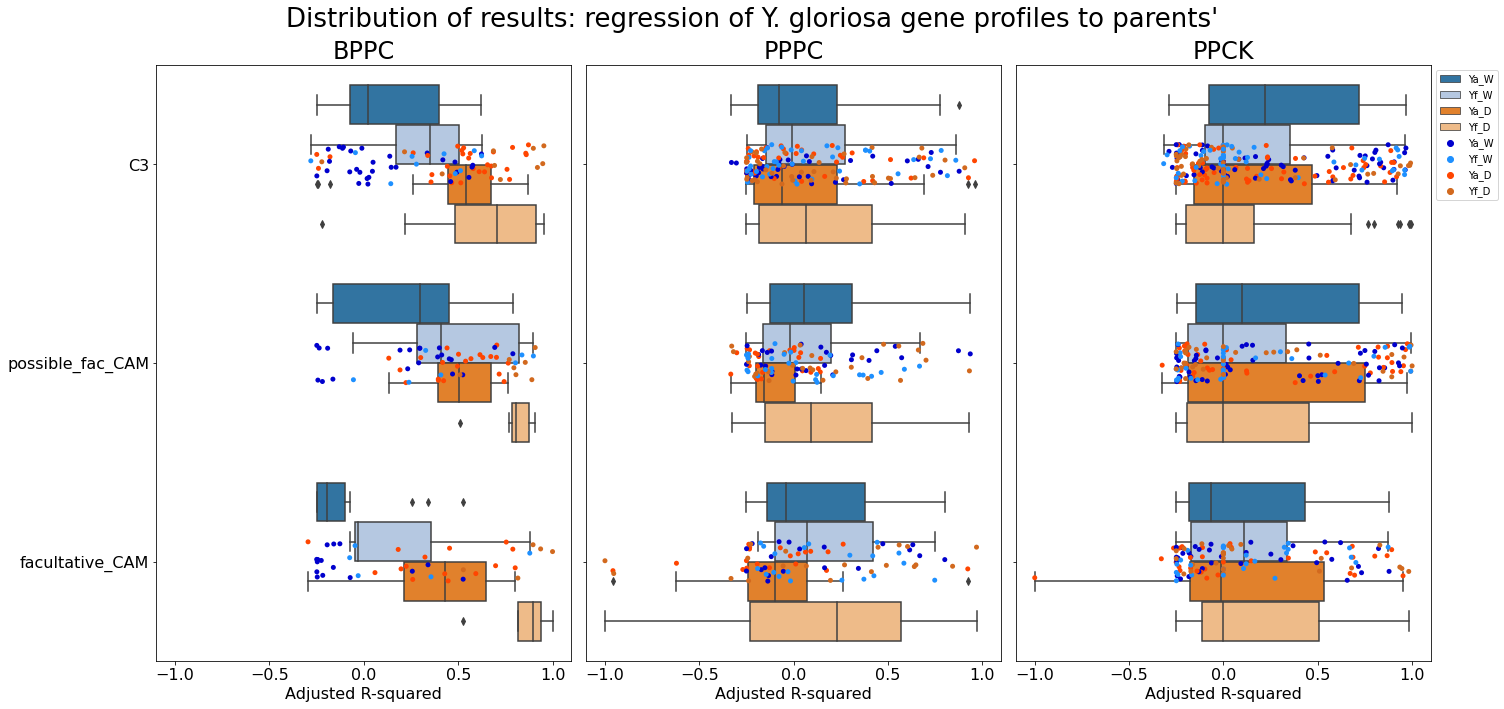

In [20]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(21,10),sharey=True,sharex=True)

plot_fam("BPPC",0,ax)
plot_fam("PPPC",1,ax)
plot_fam("PPCK",2,ax,True)

plt.suptitle("Distribution of results: regression of Y. gloriosa gene profiles to parents'",fontsize=26)

fig.tight_layout()

plt.savefig("./adjr2_boxplots_forposter.png",dpi=200,bbox_inches="tight")
plt.savefig("./adjr2_boxplots_forposter.svg",dpi=200,bbox_inches="tight")
plt.savefig("./adjr2_boxplots_forposter.pdf",dpi=200,bbox_inches="tight")

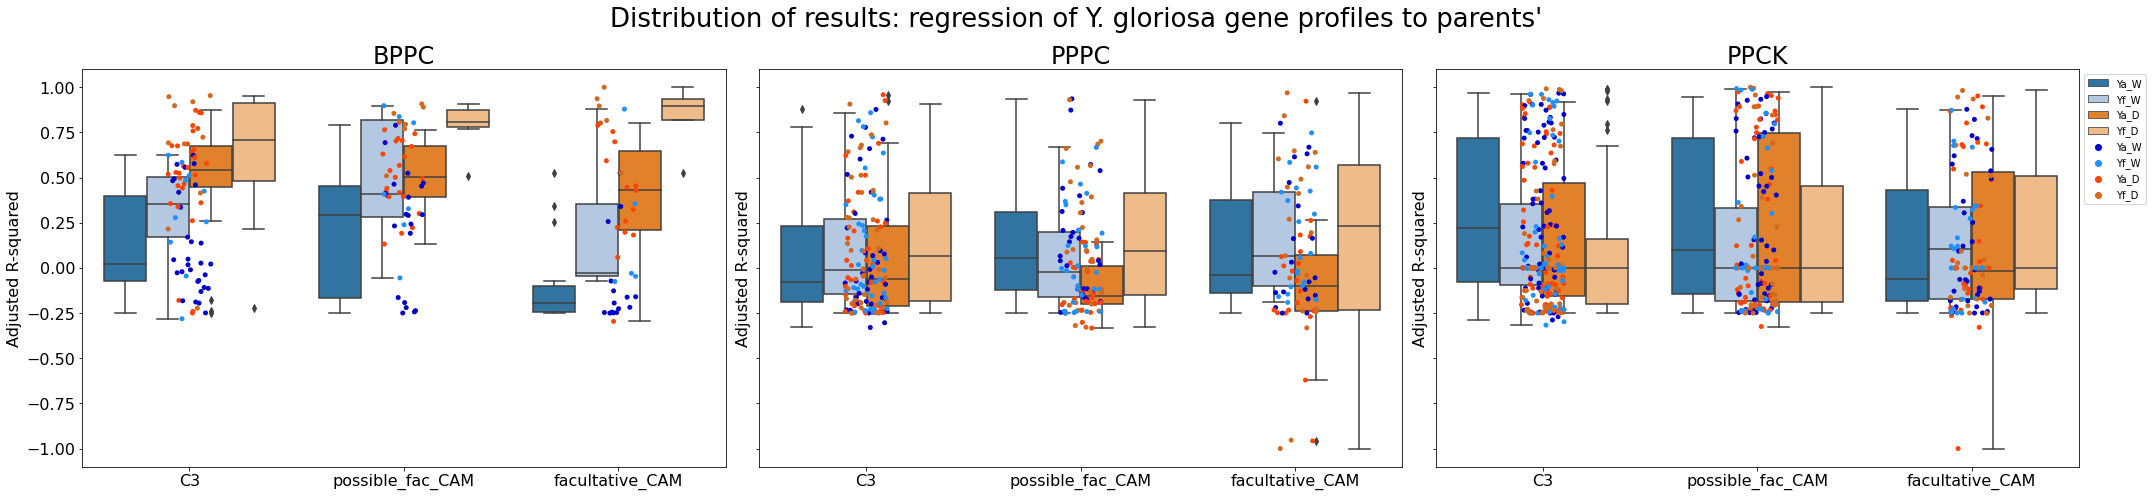

In [25]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(30,7),sharey=True,sharex=True)

plot_fam("BPPC",0,ax)
plot_fam("PPPC",1,ax)
plot_fam("PPCK",2,ax,True)

plt.suptitle("Distribution of results: regression of Y. gloriosa gene profiles to parents'",fontsize=26)

fig.tight_layout()

plt.savefig("./adjr2_boxplots_forposter_horizontal.png",dpi=200,bbox_inches="tight")
plt.savefig("./adjr2_boxplots_forposter_horizontal.svg",dpi=200,bbox_inches="tight")
plt.savefig("./adjr2_boxplots_forposter_horizontal.pdf",dpi=200,bbox_inches="tight")